<a href="https://colab.research.google.com/github/AKfrozen2/NBA_heatmap/blob/main/NBA_Shot_chart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# Creating NBA shot chart, need to install API to pull data
!pip install nba_api

In [115]:
# Import packages
import json
import math
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from nba_api.stats.endpoints import shotchartdetail
from nba_api.stats.static import players

#Call player to create map
def get_player_id(player_name):
    nba_players = players.get_players()

    for player in nba_players:
        if player['full_name'].lower() == player_name.lower():
            return player['id']

    # fallback if not found
    print(f"Player '{player_name}' not found. Using default player.")

    default_player_name = "Stephen Curry"
    for player in nba_players:
        if player['full_name'] == default_player_name:
            return player['id']

    raise ValueError("Could not find any player.")

# Choose player by name and year
chosen_player_name = input("Enter player name: ")
player_id = get_player_id(chosen_player_name)

chosen_season = input("Enter season (e.g., 2023-24): ")
if not chosen_season:
    chosen_season = "2025-26"

print(f"Retrieving data for {chosen_player_name} (ID: {player_id}) for {chosen_season}")

# Get shot data from api
def get_shot_data(player_id, season):
    response = shotchartdetail.ShotChartDetail(
        team_id=0,
        player_id=player_id,
        season_nullable=season,
        season_type_all_star="Regular Season",
        context_measure_simple="FGA"
    )

    content = json.loads(response.get_json())
    results = content["resultSets"][0]
    headers = results["headers"]
    rows = results["rowSet"]

    shot_data = pd.DataFrame(rows, columns=headers)

    shot_data["SHOT_RESULT"] = np.where(
        shot_data["EVENT_TYPE"] == "Made Shot", 1, 0
    )

    return shot_data
shot_data = get_shot_data(player_id, chosen_season)





Enter player name: bam adebayo
Enter season (e.g., 2023-24): 
Retrieving data for bam adebayo (ID: 1628389) for 2025-26


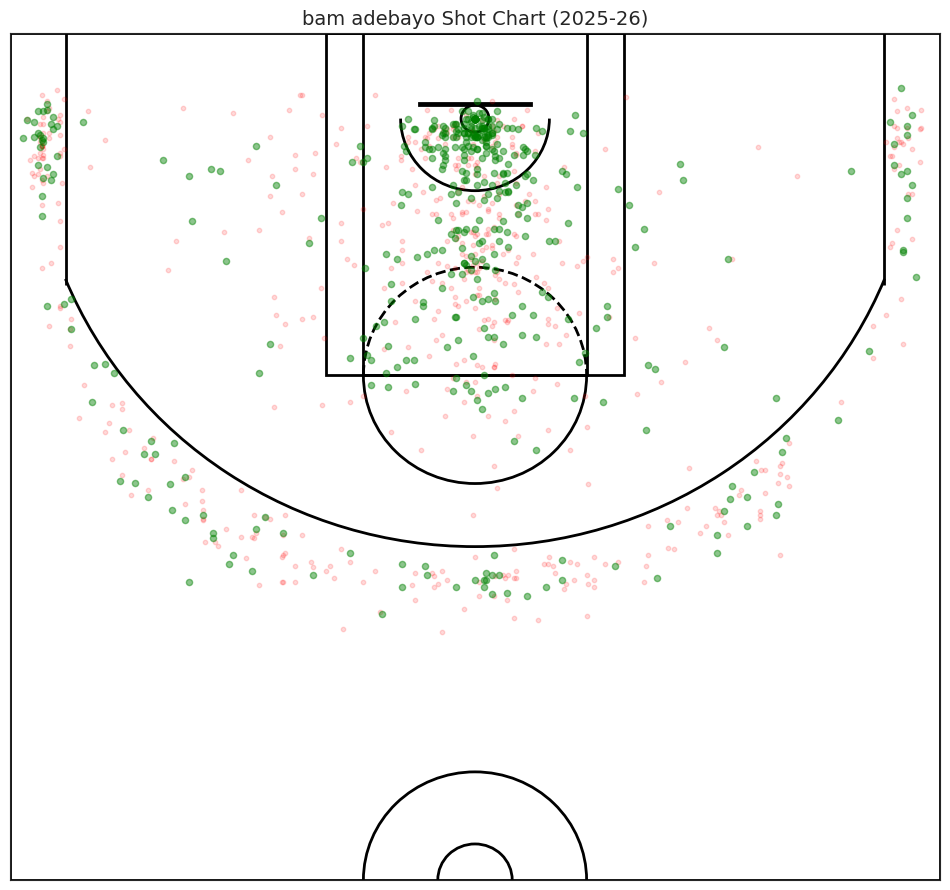

In [116]:
def plot_shot_chart(shot_data, player_name, season):
    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    makes = shot_data[shot_data["SHOT_RESULT"] == 1]
    misses = shot_data[shot_data["SHOT_RESULT"] == 0]

    ax.scatter(misses["LOC_X"], misses["LOC_Y"], color="red", alpha=0.15, s=10)
    ax.scatter(makes["LOC_X"], makes["LOC_Y"], color="green", alpha=0.45, s=20)

    ax.set_xlim(-250, 250)
    ax.set_ylim(422.5, -47.5)

    ax.set_title(f"{player_name} Shot Chart ({season})", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelbottom=False, labelleft=False)

    return fig, ax

fig, ax = plot_shot_chart(shot_data, chosen_player_name, chosen_season)
plt.show()

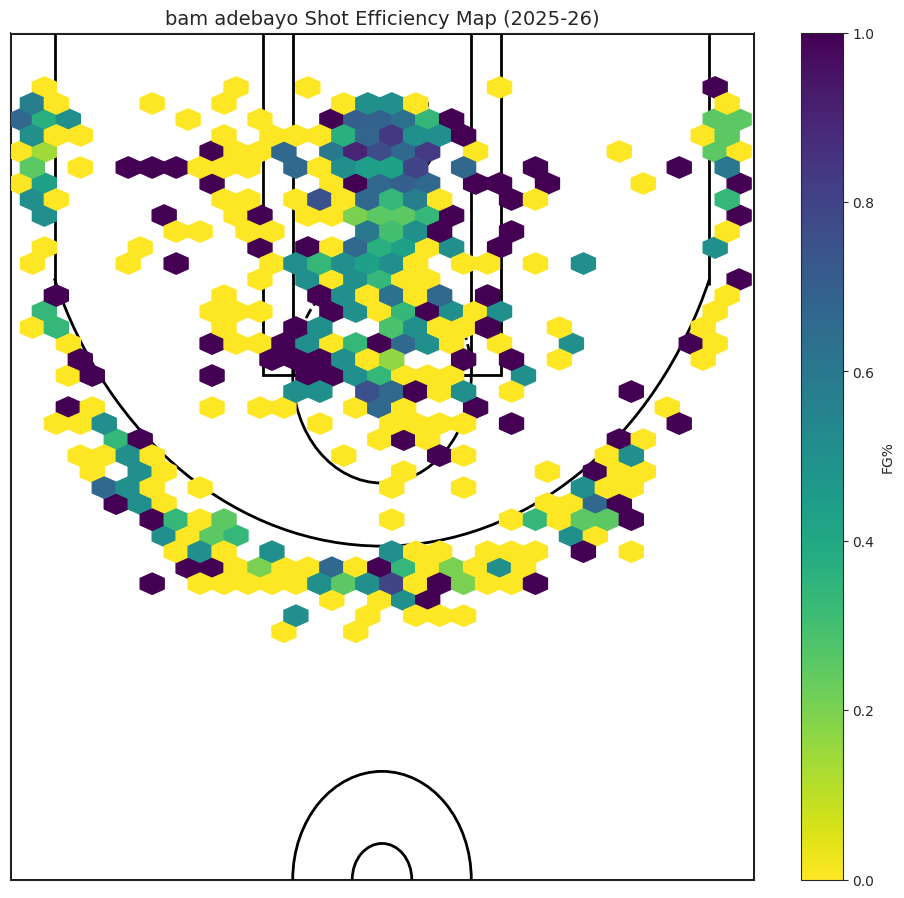

In [117]:
def plot_hex_shot_chart(shot_data, player_name, season):
    fig, ax = plt.subplots(figsize=(12, 11))
    draw_court(ax, outer_lines=True)

    hb = ax.hexbin(
        shot_data["LOC_X"],
        shot_data["LOC_Y"],
        C=shot_data["SHOT_RESULT"],
        gridsize=30,
        cmap="viridis_r",
        reduce_C_function=np.mean
    )

    ax.set_xlim(-250, 250)
    ax.set_ylim(422.5, -47.5)

    ax.set_title(f"{player_name} Shot Efficiency Map ({season})", fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelbottom=False, labelleft=False)

    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("FG%")

    return fig, ax

fig, ax = plot_hex_shot_chart(shot_data, chosen_player_name, chosen_season)
plt.show()

In [118]:
def main():
    player_name = input("Enter player name: ")
    season = input("Enter season: ")

    player_id = get_player_id(player_name)
    shot_data = get_shot_data(player_id, season)

    plot_shot_chart(shot_data, player_name, season)
    plot_hex_shot_chart(shot_data, player_name, season)

Enter player name: Lebron James
Enter season: 2025-26


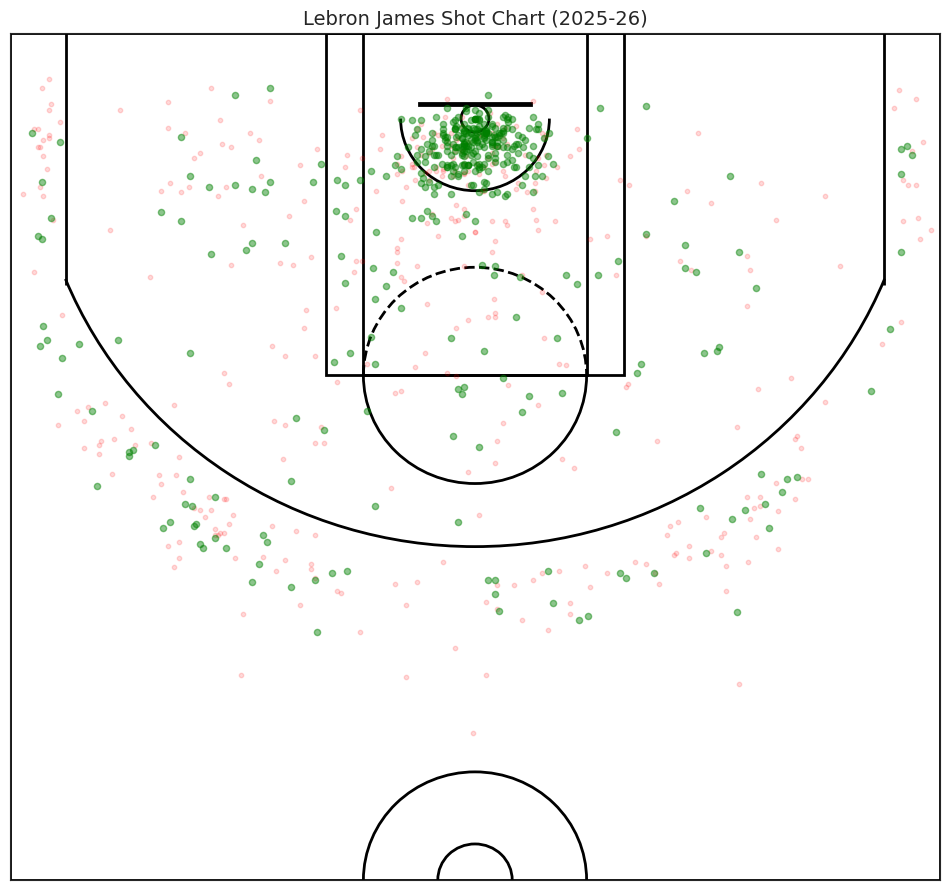

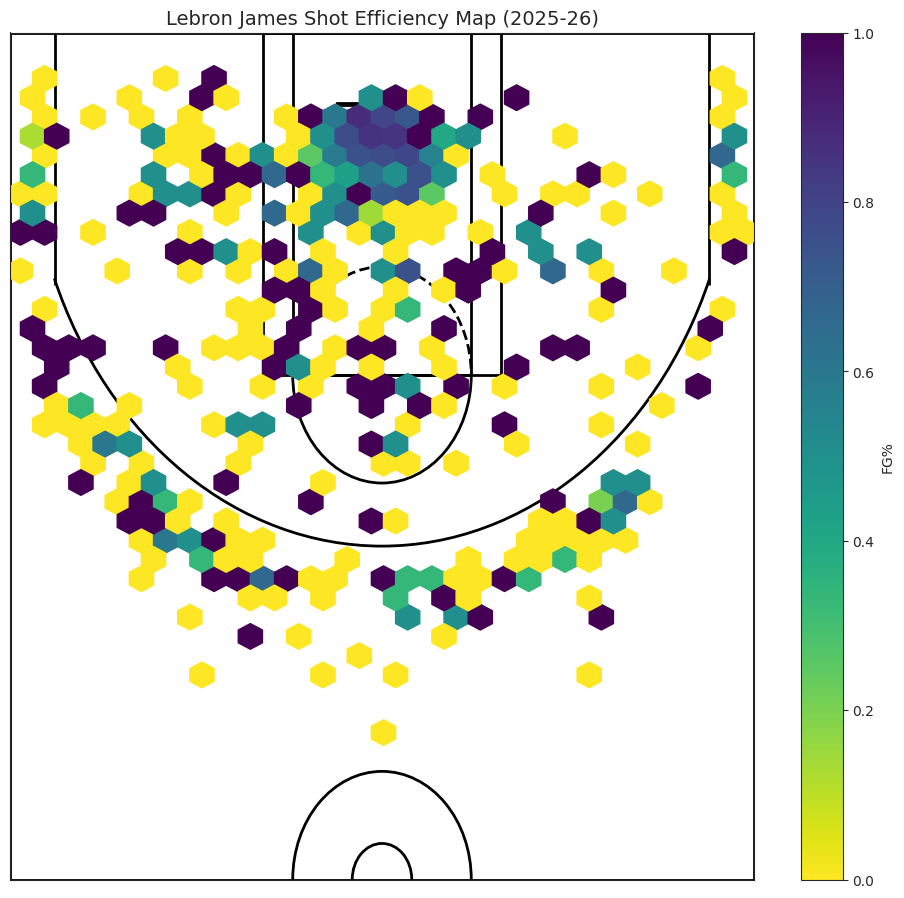

In [121]:
main()